## Data sources used

- TAHMO hourly station data: `../files/miscellaneous/Hourly GDFs/Combined_Hourly.shp`
- Copernicus hourly data: `../files/miscellaneous/Hourly GDFs/Combined_Hourly_Copernicus_Data.shp`
- CHIRPS monthly raster directory: `../files/miscellaneous/CHIRPS_Monthly_22`
- TAHMO timestamp list: `../files/miscellaneous/Hourly GDFs/Hourly_Df_Hour_List.txt`
- Copernicus timestamp list: `../files/miscellaneous/Hourly GDFs/Copernicus_Hourly_Df_Hour_List.txt`

This notebook compares monthly precipitation from TAHMO and CHIRPS for 2022, with Copernicus used as an additional hourly spatial dataset/reference alongside the CHIRPS clipping workflow.

# CHIRPS + TAHMO monthly precipitation regression (2022)

This notebook loads the 2022 TAHMO and Copernicus hourly data, processes the CHIRPS monthly rasters, aligns the monthly precipitation time series, and fits a simple linear relationship between TAHMO and CHIRPS precipitation.

Run all cells from top to bottom.

In [1]:
from pathlib import Path
import os
from datetime import datetime

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
from scipy.stats import linregress


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

project_root = Path.cwd().resolve()

# Handle running Jupyter from either:
#   1. __Cleaned_Up_Project_1/
#   2. __Cleaned_Up_Project_1/notebooks/
if project_root.name == "notebooks":
    project_root = project_root.parent
elif (
    not (project_root / "files").exists()
    and (project_root.parent / "files").exists()
):
    project_root = project_root.parent

miscellaneous_dir = project_root / "files" / "miscellaneous"
hourly_dir = miscellaneous_dir / "Hourly GDFs"

# ---------------------------------------------------------
# Input paths
# ---------------------------------------------------------

tahmo_path = hourly_dir / "Combined_Hourly.shp"

copernicus_path = (
    hourly_dir / "Combined_Hourly_Copernicus_Data.shp"
)

chirps_monthly_dir = (
    miscellaneous_dir / "CHIRPS_Monthly_22"
)

tahmo_timestamp_path = (
    hourly_dir / "Hourly_Df_Hour_List.txt"
)

copernicus_timestamp_path = (
    hourly_dir / "Copernicus_Hourly_Df_Hour_List.txt"
)

# ---------------------------------------------------------
# Check that all required inputs exist
# ---------------------------------------------------------

required_inputs = {
    "TAHMO shapefile": tahmo_path,
    "Copernicus shapefile": copernicus_path,
    "CHIRPS monthly directory": chirps_monthly_dir,
    "TAHMO timestamp list": tahmo_timestamp_path,
    "Copernicus timestamp list": copernicus_timestamp_path,
}

for input_name, path in required_inputs.items():
    if not path.exists():
        raise FileNotFoundError(
            f"{input_name} not found: {path}"
        )

print(f"Project root: {project_root}")

for input_name, path in required_inputs.items():
    print(f"Found {input_name}: {path}")

# ---------------------------------------------------------
# Load TAHMO hourly data
# ---------------------------------------------------------

tahmo_combined_hourly = gpd.read_file(tahmo_path)

tahmo_combined_hourly = tahmo_combined_hourly.rename(
    columns={
        "Precipitat": "Precip_Tahmo",
        "Temperatur": "Temp_Tahmo",
    }
)

Project root: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1
Found TAHMO shapefile: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1/files/miscellaneous/Hourly GDFs/Combined_Hourly.shp
Found Copernicus shapefile: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1/files/miscellaneous/Hourly GDFs/Combined_Hourly_Copernicus_Data.shp
Found CHIRPS monthly directory: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1/files/miscellaneous/CHIRPS_Monthly_22
Found TAHMO timestamp list: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1/files/miscellaneous/Hourly GDFs/Hourly_Df_Hour_List.txt
Found Copernicus timestamp list: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1/files/miscellaneous/Hourly GDFs/Copernicus_Hourly_Df_Hour_List.txt


In [13]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

In [2]:
with open(hourly_dir / "Hourly_Df_Hour_List.txt", "r") as f:
    my_list = [datetime.strptime(line.strip(), "%Y-%m-%d %H:%M:%S") for line in f.readlines()]

formatted_list = [dt.strftime("%Y-%m-%d %H:%M:%S") for dt in my_list]
tahmo_combined_hourly["Timestamp"] = formatted_list
tahmo_combined_hourly["Timestamp"] = pd.to_datetime(tahmo_combined_hourly["Timestamp"])

tahmo_2022 = tahmo_combined_hourly[tahmo_combined_hourly["Timestamp"].dt.year == 2022].copy()
tahmo_2022 = tahmo_2022.reset_index(drop=True)
tahmo_2022.head()

,Timestamp,Precip_Tahmo,Temp_Tahmo,Site_Name,elevation,geometry
0,2022-01-01 00:00:00,0.0,26.8,Accra_Aca,32.4,POINT (-0.2445 5.5731)
1,2022-01-01 01:00:00,0.0,26.6,Accra_Aca,32.4,POINT (-0.2445 5.5731)
2,2022-01-01 02:00:00,0.0,26.3,Accra_Aca,32.4,POINT (-0.2445 5.5731)
3,2022-01-01 03:00:00,0.0,26.2,Accra_Aca,32.4,POINT (-0.2445 5.5731)
4,2022-01-01 04:00:00,0.0,26.0,Accra_Aca,32.4,POINT (-0.2445 5.5731)


In [3]:
copernicus_hourly = gpd.read_file(copernicus_path)
copernicus_hourly = copernicus_hourly.rename(columns={"valid_time": "Timestamp", "Location_I": "Location_ID", "Precip (mm": "Precip_Coper", "Temp (C)": "Temp_Coper"})

with open(hourly_dir / "Copernicus_Hourly_Df_Hour_List.txt", "r") as f:
    my_list_2 = [datetime.strptime(line.strip(), "%Y-%m-%d %H:%M:%S") for line in f.readlines()]

formatted_list_2 = [dt.strftime("%Y-%m-%d %H:%M:%S") for dt in my_list_2]
copernicus_hourly["Timestamp"] = formatted_list_2
copernicus_hourly["Timestamp"] = pd.to_datetime(copernicus_hourly["Timestamp"])

copernicus_2022 = copernicus_hourly[copernicus_hourly["Timestamp"].dt.year == 2022].copy()
copernicus_2022 = copernicus_2022.reset_index(drop=True)
copernicus_2022.head()

,Timestamp,Temp_Coper,Precip_Coper,latitude,longitude,Location_ID,geometry
0,2022-01-01,23.968475,6.088091,6.1,-0.54,1,POINT (-0.54 6.1)
1,2022-01-01,24.608307,7.620002,6.1,-0.44,2,POINT (-0.44 6.1)
2,2022-01-01,24.779022,8.660165,6.1,-0.34,3,POINT (-0.34 6.1)
3,2022-01-01,24.719635,8.677551,6.1,-0.24,4,POINT (-0.24 6.1)
4,2022-01-01,24.869598,7.796841,6.1,-0.14,5,POINT (-0.14 6.1)


In [4]:
def process_tif_files(folder_path, geometry):
    """Process all CHIRPS monthly raster GeoTIFF files into one monthly precipitation dataframe."""
    if not folder_path.exists():
        raise FileNotFoundError(f"CHIRPS monthly folder not found: {folder_path}")

    df_combined = pd.DataFrame()
    tif_files = sorted(p for p in folder_path.iterdir() if p.suffix.lower() == ".tif")
    if not tif_files:
        raise FileNotFoundError(f"No .tif files were found in {folder_path}")

    for file_path in tif_files:
        try:
            parts = file_path.name.split(".")
            year_month = parts[2:4]
            time_value = f"{year_month[0]}-{year_month[1]}"
        except IndexError:
            print(f"Skipping file: {file_path.name} (invalid name format)")
            continue

        with rasterio.open(file_path) as dataset:
            geom = geometry.geometry.union_all()   # updated from deprecated unary_union
            out_image, out_transform = mask(dataset, [geom], crop=True)
            precip_data = out_image[0]

            rows, cols = precip_data.shape
            lon_vals, lat_vals = [], []
            for row in range(rows):
                for col in range(cols):
                    lon, lat = out_transform * (col, row)
                    lon_vals.append(lon)
                    lat_vals.append(lat)

            data_list = []
            for i in range(len(lon_vals)):
                data_list.append([lon_vals[i], lat_vals[i], precip_data[i // cols, i % cols]])

            df_clipped = pd.DataFrame(data_list, columns=["Longitude", "Latitude", "Precipitation"])
            df_clipped["Longitude"] = df_clipped["Longitude"].round(2)
            df_clipped["Latitude"] = df_clipped["Latitude"].round(2)
            df_clipped["Year-Month"] = time_value
            df_combined = pd.concat([df_combined, df_clipped], ignore_index=True)

    if df_combined.empty:
        raise ValueError(f"No monthly CHIRPS data was extracted from {folder_path}")

    df_combined["Year-Month"] = pd.to_datetime(df_combined["Year-Month"], format="%Y-%m")
    df_combined = df_combined.sort_values("Year-Month").reset_index(drop=True)
    print(f"Processed {len(tif_files)} files. Combined DataFrame shape: {df_combined.shape}")
    return df_combined

df_combined_2022 = process_tif_files(chirps_monthly_dir, copernicus_2022)
df_combined_2022.head()

Processed 12 files. Combined DataFrame shape: (1716, 4)


,Longitude,Latitude,Precipitation,Year-Month
0,-0.55,6.15,9.837756,2022-01-01
1,-0.35,5.75,7.035975,2022-01-01
2,-0.30,5.75,0.000000,2022-01-01
3,-0.25,5.75,5.072530,2022-01-01
4,-0.20,5.75,0.000000,2022-01-01


In [5]:
gdf_combined_2022 = gpd.GeoDataFrame(
    df_combined_2022,
    geometry=gpd.points_from_xy(df_combined_2022["Longitude"], df_combined_2022["Latitude"]),
    crs="EPSG:4326",
)

unique_geometries_2022 = gdf_combined_2022["geometry"].unique()
geometry_id_mapping_2022 = {geom: f"Geom_{i + 1}" for i, geom in enumerate(unique_geometries_2022)}
gdf_combined_2022["Geometry_ID"] = gdf_combined_2022["geometry"].map(geometry_id_mapping_2022)
gdf_combined_2022.head()

,Longitude,Latitude,Precipitation,Year-Month,geometry,Geometry_ID
0,-0.55,6.15,9.837756,2022-01-01,POINT (-0.55 6.15),Geom_1
1,-0.35,5.75,7.035975,2022-01-01,POINT (-0.35 5.75),Geom_2
2,-0.30,5.75,0.000000,2022-01-01,POINT (-0.3 5.75),Geom_3
3,-0.25,5.75,5.072530,2022-01-01,POINT (-0.25 5.75),Geom_4
4,-0.20,5.75,0.000000,2022-01-01,POINT (-0.2 5.75),Geom_5


In [6]:
tahmo_2022["Time"] = pd.to_datetime(tahmo_2022["Timestamp"])
tahmo_2022["Year-Month"] = tahmo_2022["Timestamp"].dt.to_period("M")
monthly_precip_tahmo_2022 = (
    tahmo_2022.groupby(["Site_Name", "geometry", "Year-Month"])["Precip_Tahmo"].sum().reset_index()
)

monthly_precip_tahmo_2022_gdf = gpd.GeoDataFrame(
    monthly_precip_tahmo_2022,
    geometry=monthly_precip_tahmo_2022["geometry"],
    crs="EPSG:4326",
)
monthly_precip_tahmo_2022_gdf["Year-Month"] = monthly_precip_tahmo_2022_gdf["Year-Month"].dt.to_timestamp()
monthly_precip_tahmo_2022_gdf.head()

,Site_Name,geometry,Year-Month,Precip_Tahmo
0,Accra_Aca,POINT (-0.2445 5.5731),2022-01-01,0.034
1,Accra_Aca,POINT (-0.2445 5.5731),2022-02-01,0.000
2,Accra_Aca,POINT (-0.2445 5.5731),2022-03-01,5.630
3,Accra_Aca,POINT (-0.2445 5.5731),2022-04-01,154.752
4,Accra_Aca,POINT (-0.2445 5.5731),2022-05-01,520.899


In [7]:
def filter_keep_one_instance(df, column_name):
    mask = ~df[column_name].duplicated(keep="first")
    return df[mask].copy()

filtered_tahmo_2022 = filter_keep_one_instance(monthly_precip_tahmo_2022_gdf, "Site_Name")
filtered_chirps_2022 = filter_keep_one_instance(gdf_combined_2022, "Geometry_ID")

def count_nearby_locations_with_names(tahmo_gdf, chirps_gdf, distance_meters):
    tahmo_projected = tahmo_gdf.to_crs(epsg=3857)
    chirps_projected = chirps_gdf.to_crs(epsg=3857)
    chirps_projected["buffer"] = chirps_projected.geometry.buffer(distance_meters)
    tahmo_counts = []
    tahmo_names = []

    for buffer_geom in chirps_projected["buffer"]:
        nearby_locations = tahmo_projected[tahmo_projected.geometry.within(buffer_geom)]
        tahmo_counts.append(nearby_locations.shape[0])
        tahmo_names.append(", ".join(nearby_locations["Site_Name"]))

    chirps_gdf = chirps_gdf.copy()
    chirps_gdf["tahmo_count"] = tahmo_counts
    chirps_gdf["tahmo_names"] = tahmo_names
    return chirps_gdf


### Specify Distance 

buffer_df_2022 = count_nearby_locations_with_names(filtered_tahmo_2022, filtered_chirps_2022, 6000)
dict_2022 = buffer_df_2022.set_index("Geometry_ID")["tahmo_names"].to_dict()
filtered_site_dict_2022 = {k: v for k, v in dict_2022.items() if v != ""}
filtered_site_dict_2022

{'Geom_2': 'Nsawam',
 'Geom_4': 'Agri_Impact, Berekuso',
 'Geom_5': 'Agri_Impact, Berekuso',
 'Geom_17': 'G_Met, Madina',
 'Geom_27': 'Nsawam',
 'Geom_28': 'Nsawam',
 'Geom_29': 'Agri_Impact, Berekuso',
 'Geom_30': 'Agri_Impact, Berekuso',
 'Geom_34': 'Nsawam',
 'Geom_36': 'Safisana',
 'Geom_38': 'Accra_Girls',
 'Geom_44': 'Accra_Aca, Accra_Girls',
 'Geom_47': 'Accra_Aca',
 'Geom_48': 'Accra_Aca, Accra_Girls',
 'Geom_53': 'Safisana',
 'Geom_54': 'Accra_Aca, St_Johns',
 'Geom_61': 'St_Johns',
 'Geom_63': 'Accra_Girls, G_Met, Legon, Madina, St_Johns',
 'Geom_65': 'Safisana, Temasco',
 'Geom_70': 'G_Met, Legon, Madina',
 'Geom_72': 'Legon, Madina',
 'Geom_73': 'Nsawam'}

In [8]:
def filter_dataframes(chirps_df, tahmo_df, filter_dict):
    chirps_df = chirps_df[chirps_df["Geometry_ID"].apply(lambda x: bool(filter_dict.get(x, "").strip()))].copy()
    valid_site_names = {
        site_name.strip()
        for value in filter_dict.values() if value
        for site_name in value.split(",")
    }
    tahmo_df = tahmo_df[tahmo_df["Site_Name"].isin(valid_site_names)].copy()
    chirps_df = chirps_df[["Year-Month", "Precipitation", "Geometry_ID"]].reset_index(drop=True)
    tahmo_df = tahmo_df[["Year-Month", "Precip_Tahmo", "Site_Name"]].reset_index(drop=True)
    return chirps_df, tahmo_df

filtered_chirps_2022, filtered_tahmo_2022 = filter_dataframes(
    gdf_combined_2022,
    monthly_precip_tahmo_2022_gdf,
    filtered_site_dict_2022,
)
print(filtered_chirps_2022.shape)
print(filtered_tahmo_2022.shape)

(264, 3)
(88, 3)


In [9]:
def average_and_merge_dfs(dfs, on_column, avg_column):
    if not dfs:
        raise ValueError("At least one DataFrame is required.")

    dfs = [df.copy() for df in dfs]

    if len(dfs) == 1:
        result = dfs[0].copy()
        result[f"Average_{avg_column}"] = result[avg_column]
        return result

    temp_dfs = []
    for i, df in enumerate(dfs):
        temp_dfs.append(df[[on_column, avg_column]].copy().rename(columns={avg_column: f"{avg_column}_{i + 1}"}))

    merged_temp_df = temp_dfs[0].copy()
    for temp_df in temp_dfs[1:]:
        merged_temp_df = pd.merge(merged_temp_df, temp_df, on=on_column, how="inner")

    avg_columns = [col for col in merged_temp_df.columns if col.startswith(avg_column)]
    merged_temp_df = merged_temp_df.copy()
    merged_temp_df[f"Average_{avg_column}"] = merged_temp_df[avg_columns].mean(axis=1)
    merged_temp_df = merged_temp_df[[on_column, f"Average_{avg_column}"]].copy()
    final_merged_df = dfs[0].merge(merged_temp_df, on=on_column, how="inner")
    return final_merged_df

def average_and_merge_site_dfs_from_dict_with_copernicus_MONTHLY(dfs, on_column, avg_column, site_dict, chirps_df, chirps_column):
    if not site_dict:
        raise ValueError("The site_dict should contain at least one entry.")

    merged_results = []
    for location_id, site_list in site_dict.items():
        site_names = [s.strip() for s in site_list.split(",") if s.strip()]
        filtered_dfs = [dfs[dfs["Site_Name"] == site_name].copy() for site_name in site_names]
        merged_df = average_and_merge_dfs(filtered_dfs, on_column, avg_column)
        merged_df = merged_df.copy()
        merged_df.loc[:, "Geometry_ID"] = location_id
        filtered_chirps = chirps_df[chirps_df["Geometry_ID"] == location_id].copy()
        aligned_df = pd.merge(
            merged_df,
            filtered_chirps[[on_column, chirps_column]],
            on=on_column,
            how="inner",
        )
        if aligned_df.empty:
            raise ValueError(f"No matching rows found between merged_df and Chirps data for Geometry_ID {location_id}")
        aligned_df = aligned_df.copy()
        aligned_df.loc[:, "Precip_Chirps"] = aligned_df[chirps_column]
        merged_results.append(aligned_df)

    final_merged_df = pd.concat(merged_results, ignore_index=True)
    return final_merged_df

result_2022_df = average_and_merge_site_dfs_from_dict_with_copernicus_MONTHLY(
    dfs=filtered_tahmo_2022,
    on_column="Year-Month",
    avg_column="Precip_Tahmo",
    site_dict=filtered_site_dict_2022,
    chirps_df=filtered_chirps_2022,
    chirps_column="Precipitation",
)
result_2022_df.head()

,Year-Month,Precip_Tahmo,Site_Name,Average_Precip_Tahmo,Geometry_ID,Precipitation,Precip_Chirps
0,2022-01-01,0.765,Nsawam,0.765,Geom_2,7.035975,7.035975
1,2022-02-01,26.032,Nsawam,26.032,Geom_2,23.751717,23.751717
2,2022-03-01,70.104,Nsawam,70.104,Geom_2,57.788425,57.788425
3,2022-04-01,92.086,Nsawam,92.086,Geom_2,171.504700,171.504700
4,2022-05-01,5.135,Nsawam,5.135,Geom_2,252.660110,252.660110


In [18]:
def plot_linear_fit(
    df,
    x_col,
    y_col,
    x_label=None,
    y_label=None,
    title=None,

    # Figure and saving
    figsize=(8, 8),
    dpi=300,
    save_path=None,

    # Axis limits and scaling
    axis_limits=None,
    equal_aspect=True,

    # Scatter points
    point_label='Data points',
    point_color='steelblue',
    point_alpha=0.40,
    point_size=20,

    # Fitted regression line
    fit_color='darkorange',
    fit_linewidth=2,
    fit_linestyle='-',

    # Axis labels
    x_label_fontsize=14,
    y_label_fontsize=14,
    x_label_fontweight='bold',
    y_label_fontweight='bold',
    x_labelpad=10,
    y_labelpad=10,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,

    # Gridlines
    show_grid=True,
    grid_alpha=0.20,
    grid_color='grey',
    grid_linestyle='-',
    grid_linewidth=0.8,

    # Legend
    show_legend=True,
    legend_fontsize=12,
    legend_loc='upper left',
    legend_bbox=None,

    # Panel label using ax.transAxes
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_color='black',
    panel_label_ha='left',
    panel_label_va='top',

    # Spines
    hide_top_spine=True,
    hide_right_spine=True,
):
    """
    Plot two variables and their fitted linear regression line.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the variables to plot.

    x_col, y_col : str
        Column names for the x- and y-variables.

    axis_limits : tuple or None
        When supplied, applies the same numerical limits to both axes.

    equal_aspect : bool
        If True, one x-axis unit has the same physical length as one
        y-axis unit.

    panel_label : str or None
        Optional panel label, such as 'a', 'b', 'c', or 'd'. Its
        position is specified in axes-relative coordinates.

    Returns
    -------
    slope, intercept, r_value, p_value, std_err
        Linear-regression statistics.
    """

    # Keep complete x-y pairs and sort x for a clean regression line
    plot_df = (
        df[[x_col, y_col]]
        .dropna()
        .sort_values(x_col)
        .copy()
    )

    if len(plot_df) < 2:
        raise ValueError(
            'At least two complete observations are required.'
        )

    x = plot_df[x_col]
    y = plot_df[y_col]

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(
        x,
        y
    )

    fitted_values = slope * x + intercept
    r_squared = r_value**2

    # Figure
    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi
    )

    # Scatter points
    ax.scatter(
        x,
        y,
        label=point_label,
        color=point_color,
        alpha=point_alpha,
        s=point_size
    )

    # Fitted regression line
    ax.plot(
        x,
        fitted_values,
        label=(
            fr'Linear fit ($R$ = {r_value:.2f}, '
            fr'$R^2$ = {r_squared:.2f})'
        ),
        color=fit_color,
        linewidth=fit_linewidth,
        linestyle=fit_linestyle
    )

    # Axis labels
    ax.set_xlabel(
        x_label or x_col,
        fontsize=x_label_fontsize,
        fontweight=x_label_fontweight,
        labelpad=x_labelpad
    )

    ax.set_ylabel(
        y_label or y_col,
        fontsize=y_label_fontsize,
        fontweight=y_label_fontweight,
        labelpad=y_labelpad
    )

    # Optional title
    if title is not None:
        ax.set_title(title)

    # Same numerical limits for both axes
    if axis_limits is not None:
        ax.set_xlim(axis_limits)
        ax.set_ylim(axis_limits)

    # Ensure one unit has the same physical length on both axes
    if equal_aspect:
        ax.set_aspect(
            'equal',
            adjustable='box'
        )

    # Tick labels
    ax.tick_params(
        axis='x',
        labelsize=x_tick_fontsize
    )

    ax.tick_params(
        axis='y',
        labelsize=y_tick_fontsize
    )

    # Gridlines
    if show_grid:
        ax.grid(
            True,
            color=grid_color,
            alpha=grid_alpha,
            linestyle=grid_linestyle,
            linewidth=grid_linewidth
        )

    # Spines
    if hide_top_spine:
        ax.spines['top'].set_visible(False)

    if hide_right_spine:
        ax.spines['right'].set_visible(False)

    # Legend
    if show_legend:
        legend_kwargs = {
            'fontsize': legend_fontsize,
            'loc': legend_loc
        }

        if legend_bbox is not None:
            legend_kwargs['bbox_to_anchor'] = legend_bbox

        ax.legend(**legend_kwargs)

    # Panel label in axes-relative coordinates
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            panel_label,
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            color=panel_label_color,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False
        )

    plt.tight_layout()

    # Save if a path is supplied
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    return slope, intercept, r_value, p_value, std_err

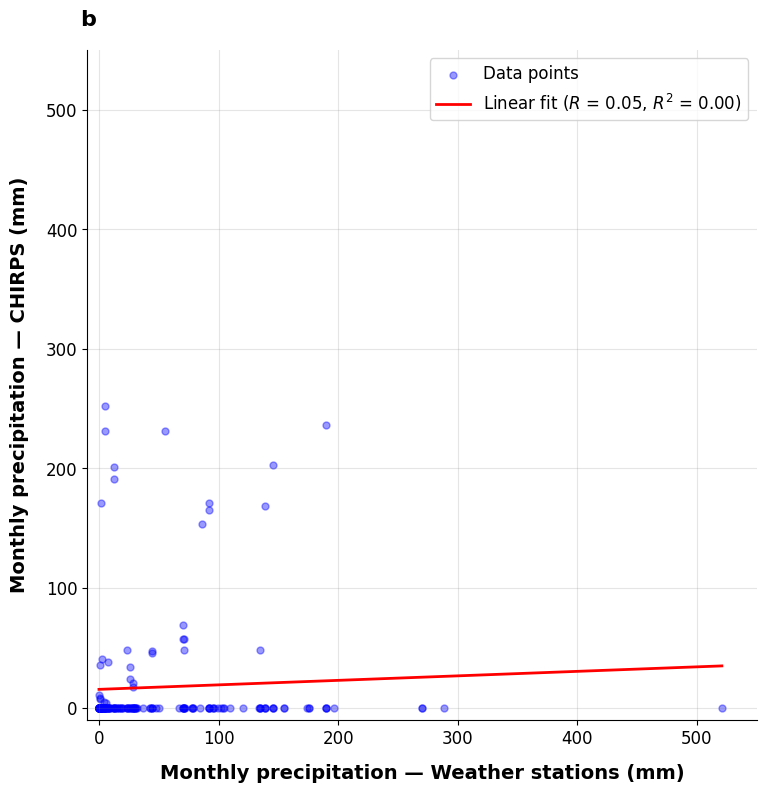

In [20]:
slope, intercept, r_value, p_value, std_err = plot_linear_fit(
    df=result_2022_df,
    x_col='Average_Precip_Tahmo',
    y_col='Precip_Chirps',

    x_label='Monthly precipitation — Weather stations (mm)',
    y_label='Monthly precipitation — CHIRPS (mm)',
    title=None,

    # Figure and saving
    figsize=(8, 8),
    dpi=100,
    
    # Use the same range on both axes
    axis_limits=(-10, 550),  
    equal_aspect=True,

    # Scatter points
    point_color='blue',
    point_alpha=0.40,
    point_size=25,

    # Panel label
    panel_label='b',
    panel_label_x=-0.01,
    panel_label_y=1.06,
    panel_label_fontsize=16,

    # Regression line
    fit_color='red',
    fit_linewidth=2,
    fit_linestyle='-',

    # Axis labels
    x_label_fontsize=14,
    y_label_fontsize=14,
    x_label_fontweight='bold',
    y_label_fontweight='bold',
    x_labelpad=12,
    y_labelpad=12,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,

    # Gridlines
    show_grid=True,
    grid_alpha=0.20,
    grid_color='grey',

    # Legend
    show_legend=True,
    legend_fontsize=12,
    legend_loc='upper right',

    # Spines
    hide_top_spine=True,
    hide_right_spine=True, 
    
    save_path = (PLOTS_DIR/ 'CHIRPS_regression.png')

)